<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/Pertemuan%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math
from google.colab.patches import cv2_imshow
from google.colab import drive


IMAGE_DIR = '/content/drive/MyDrive/PCVK/'

nomor 1

Menggunakan rumus $g(x,y) = 255 - f(x,y)$

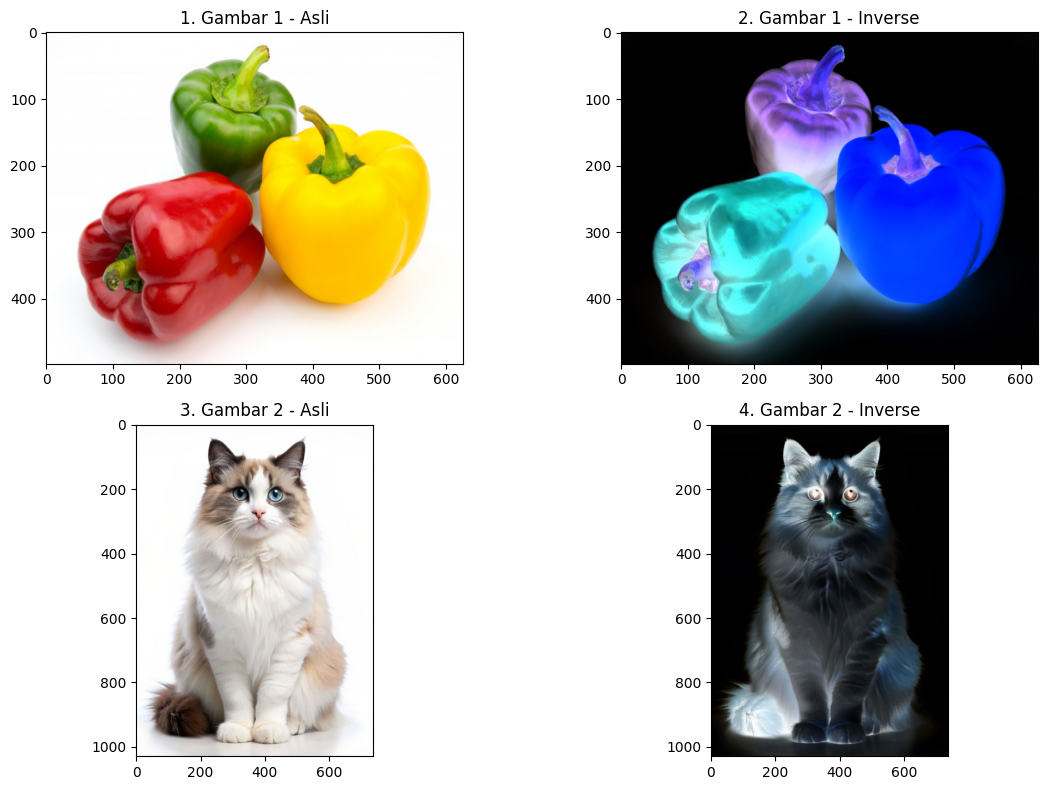

In [6]:
img1 = cv.imread(IMAGE_DIR + 'peppers.jpg')
img2 = cv.imread(IMAGE_DIR + 'kucing1.jpg')

img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

img1_inv = 255 - img1_rgb
img2_inv = 255 - img2_rgb

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img1_rgb); plt.title("1. Gambar 1 - Asli")
plt.subplot(2, 2, 2); plt.imshow(img1_inv); plt.title("2. Gambar 1 - Inverse")
plt.subplot(2, 2, 3); plt.imshow(img2_rgb); plt.title("3. Gambar 2 - Asli")
plt.subplot(2, 2, 4); plt.imshow(img2_inv); plt.title("4. Gambar 2 - Inverse")
plt.tight_layout()
plt.show()

nomor 2

Menggunakan rumus $g(x,y) = \alpha \cdot f(x,y) + \beta$.

Masukkan tingkat kecerahan (misal 10): 10
Masukkan kontras (misal 1.5): 1.5


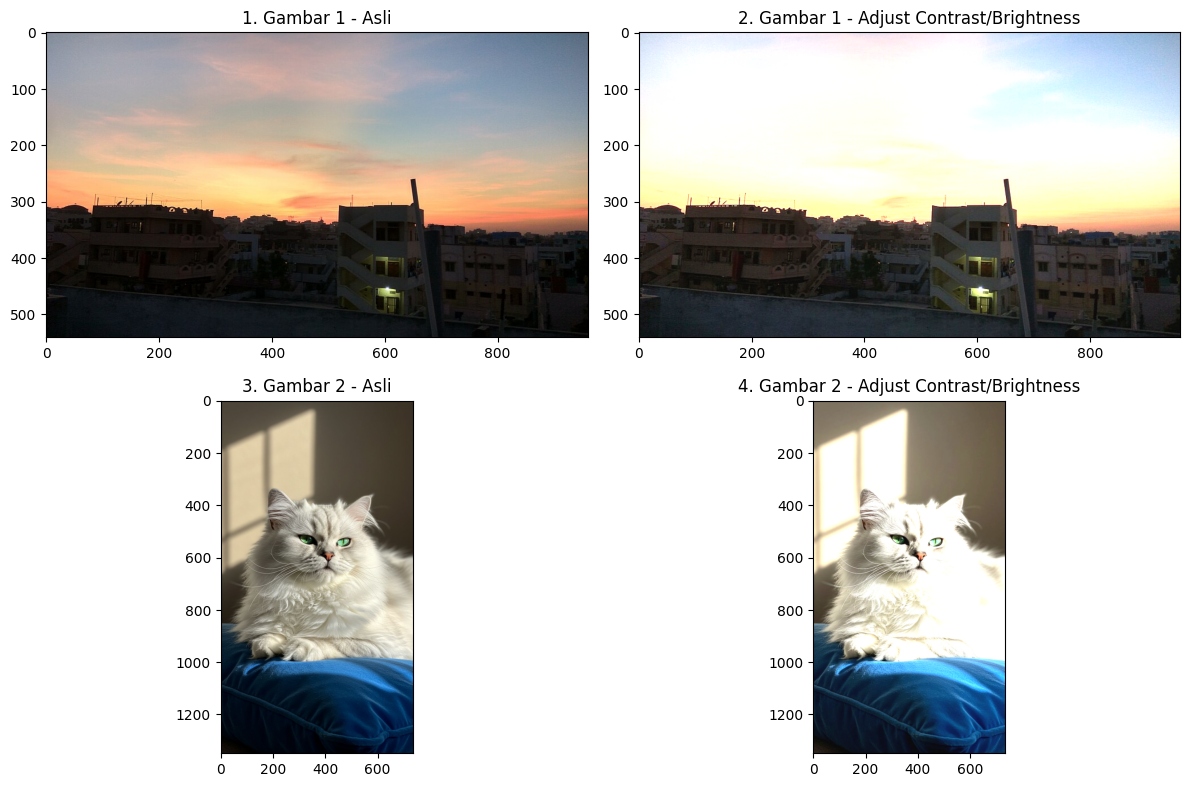

In [8]:
img1 = cv.imread(IMAGE_DIR + 'sunset.jpg')
img2 = cv.imread(IMAGE_DIR + 'kucing2.jpg')

img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

brightness = float(input("Masukkan tingkat kecerahan (misal 10): "))
contrast = float(input("Masukkan kontras (misal 1.5): "))

res1 = cv.convertScaleAbs(img1_rgb, alpha=contrast, beta=brightness)
res2 = cv.convertScaleAbs(img2_rgb, alpha=contrast, beta=brightness)


plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img1_rgb); plt.title("1. Gambar 1 - Asli")
plt.subplot(2, 2, 2); plt.imshow(res1); plt.title("2. Gambar 1 - Adjust Contrast/Brightness")
plt.subplot(2, 2, 3); plt.imshow(img2_rgb); plt.title("3. Gambar 2 - Asli")
plt.subplot(2, 2, 4); plt.imshow(res2); plt.title("4. Gambar 2 - Adjust Contrast/Brightness")
plt.tight_layout()
plt.show()

nomor 3

menggunakan rumus:
$$s = c \cdot \log(1 + r)$$

Masukkan nilai kecerahan / c (misal 50): 50


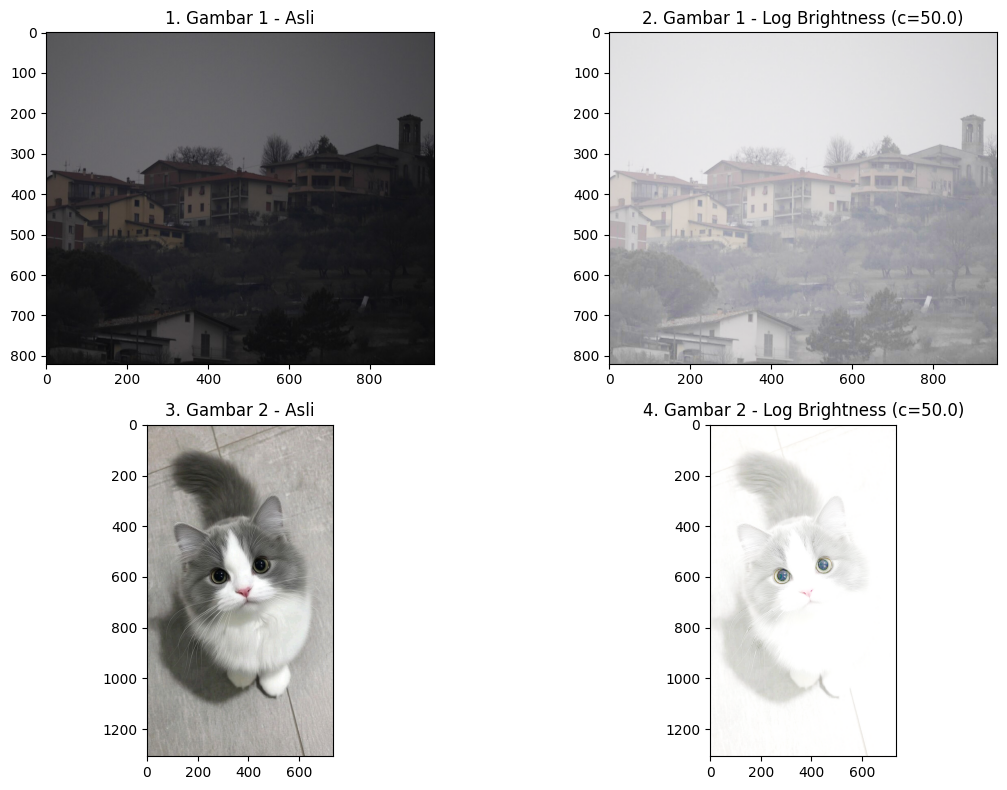

In [9]:
img1 = cv.imread(IMAGE_DIR + 'houses.jpg')
img2 = cv.imread(IMAGE_DIR + 'kucing3.jpg')

img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

c = float(input("Masukkan nilai kecerahan / c (misal 50): "))

# Fungsi Logarithmic
def log_transform(img, c_val):
    img_float = img.astype(np.float32)
    log_img = c_val * (np.log(1 + img_float))
    return np.clip(log_img, 0, 255).astype(np.uint8)

res1 = log_transform(img1_rgb, c)
res2 = log_transform(img2_rgb, c)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img1_rgb); plt.title("1. Gambar 1 - Asli")
plt.subplot(2, 2, 2); plt.imshow(res1); plt.title(f"2. Gambar 1 - Log Brightness (c={c})")
plt.subplot(2, 2, 3); plt.imshow(img2_rgb); plt.title("3. Gambar 2 - Asli")
plt.subplot(2, 2, 4); plt.imshow(res2); plt.title(f"4. Gambar 2 - Log Brightness (c={c})")
plt.tight_layout()
plt.show()

nomor 4

Rumus Averaging:$$\text{Gray} = \frac{R + G + B}{3}$$Rumus Luminance:$$\text{Gray} = 0.21R + 0.72G + 0.07B$$

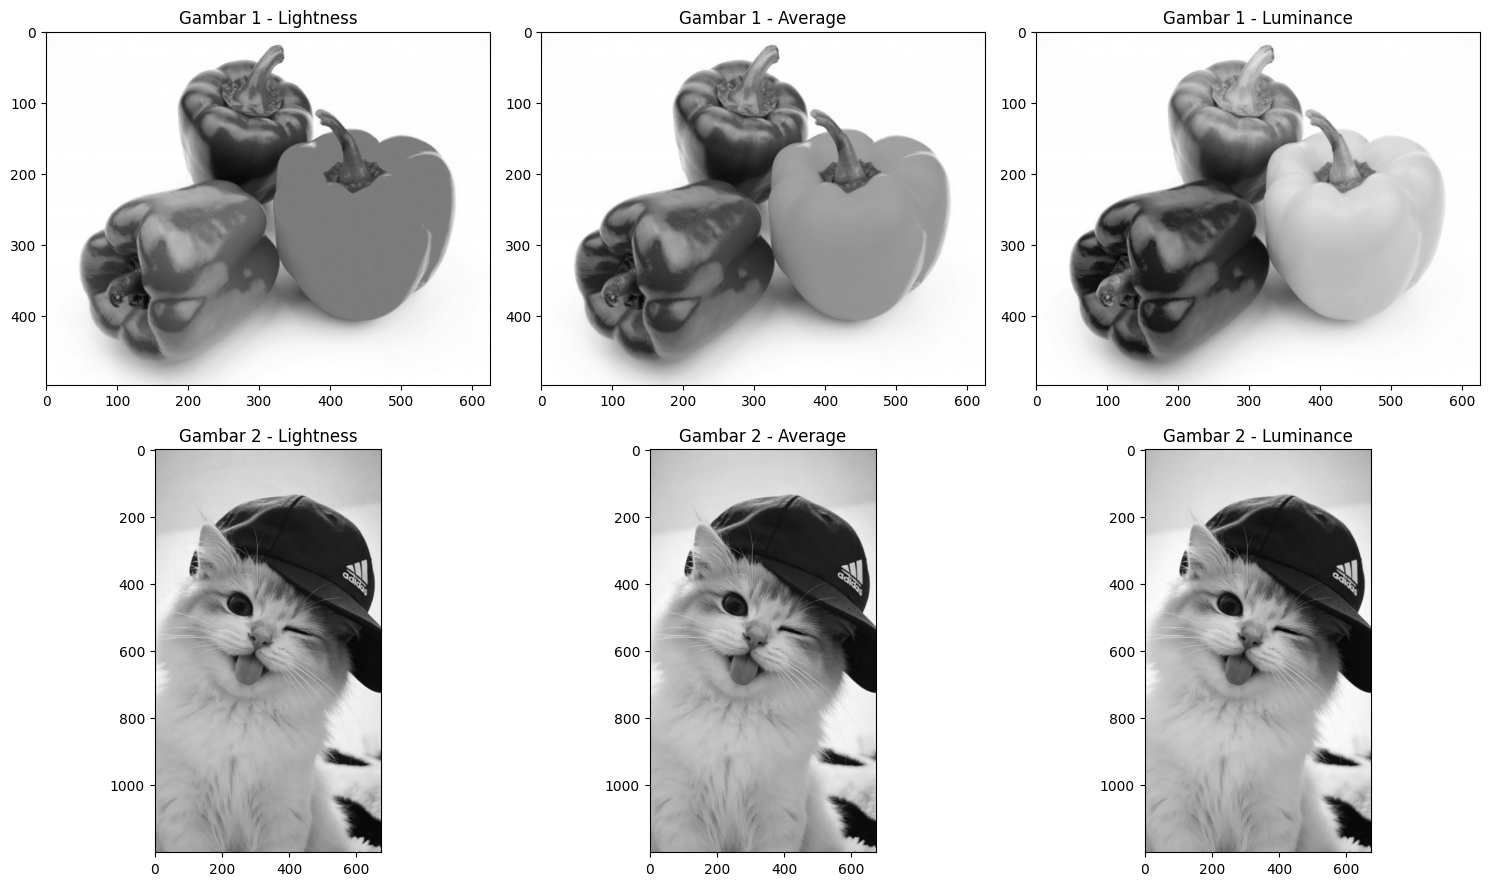

In [12]:
img1 = cv.imread(IMAGE_DIR + 'peppers.jpg')
img2 = cv.imread(IMAGE_DIR + 'kucing4.jpg')

img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

def to_grayscale_3methods(img_rgb):
    R = img_rgb[:, :, 0].astype(np.float32)
    G = img_rgb[:, :, 1].astype(np.float32)
    B = img_rgb[:, :, 2].astype(np.float32)

    max_rgb = np.maximum(np.maximum(R, G), B)
    min_rgb = np.minimum(np.minimum(R, G), B)
    gray_lightness = ((max_rgb + min_rgb) / 2).astype(np.uint8)

    gray_avg = ((R + G + B) / 3).astype(np.uint8)

    gray_lum = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    return gray_lightness, gray_avg, gray_lum

light1, avg1, lum1 = to_grayscale_3methods(img1_rgb)
light2, avg2, lum2 = to_grayscale_3methods(img2_rgb)

plt.figure(figsize=(15, 9))

plt.subplot(2, 3, 1); plt.imshow(light1, cmap='gray'); plt.title("Gambar 1 - Lightness")
plt.subplot(2, 3, 2); plt.imshow(avg1, cmap='gray'); plt.title("Gambar 1 - Average")
plt.subplot(2, 3, 3); plt.imshow(lum1, cmap='gray'); plt.title("Gambar 1 - Luminance")

plt.subplot(2, 3, 4); plt.imshow(light2, cmap='gray'); plt.title("Gambar 2 - Lightness")
plt.subplot(2, 3, 5); plt.imshow(avg2, cmap='gray'); plt.title("Gambar 2 - Average")
plt.subplot(2, 3, 6); plt.imshow(lum2, cmap='gray'); plt.title("Gambar 2 - Luminance")

plt.tight_layout()
plt.show()

nomor 5

$$\text{Output}(x, y) = \begin{cases} \text{Citra RGB}(x, y), & \text{jika } \text{HSV}(x, y) \in \text{Range Merah} \\ \text{Citra Grayscale}(x, y), & \text{lainnya} \end{cases}$$

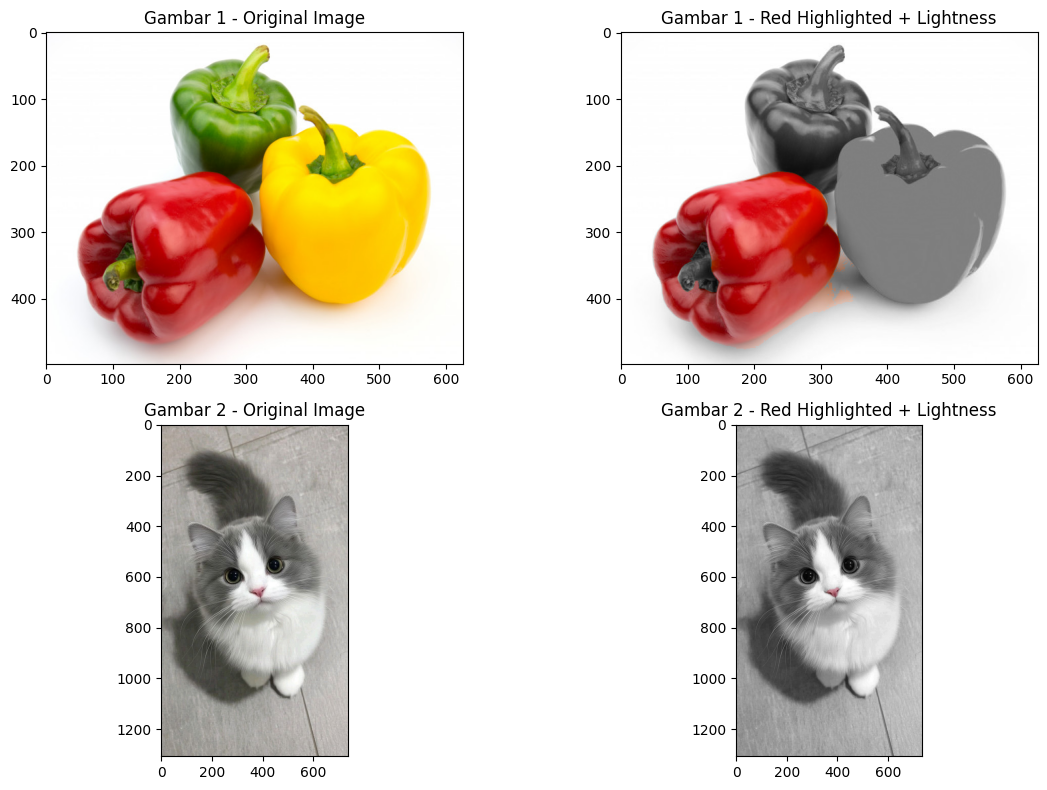

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def process_selective_lightness(image_path):
    img_bgr = cv.imread(image_path)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    R = img_rgb[:, :, 0].astype(np.float32)
    G = img_rgb[:, :, 1].astype(np.float32)
    B = img_rgb[:, :, 2].astype(np.float32)

    gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

    gray_lightness_3ch = cv.merge([gray_lightness, gray_lightness, gray_lightness])

    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
    mask_red = mask1 | mask2

    result_rgb = np.where(mask_red[:, :, None] == 255, img_rgb, gray_lightness_3ch)

    return img_rgb, result_rgb

path_img1 = '/content/drive/MyDrive/PCVK/peppers.jpg'
path_img2 = '/content/drive/MyDrive/PCVK/kucing3.jpg'

orig1, res1 = process_selective_lightness(path_img1)
orig2, res2 = process_selective_lightness(path_img2)

plt.figure(figsize=(12, 8))

# Gambar 1
plt.subplot(2, 2, 1)
plt.title('Gambar 1 - Original Image')
plt.imshow(orig1)
plt.axis('on')

plt.subplot(2, 2, 2)
plt.title('Gambar 1 - Red Highlighted + Lightness')
plt.imshow(res1)
plt.axis('on')

# Gambar 2
plt.subplot(2, 2, 3)
plt.title('Gambar 2 - Original Image')
plt.imshow(orig2)
plt.axis('on')

plt.subplot(2, 2, 4)
plt.title('Gambar 2 - Red Highlighted + Lightness')
plt.imshow(res2)
plt.axis('on')

plt.tight_layout()
plt.show()

nomor 6

Rumus:$$s = c \cdot r^{\gamma}$$Diimplementasikan dalam OpenCV sebagai:$$I_{\text{out}} = 255 \cdot \left(\frac{I_{\text{in}}}{255}\right)^{\frac{1}{\gamma}}$$

Masukkan nilai Gamma (misal 0.5 atau 3.0): 0.5


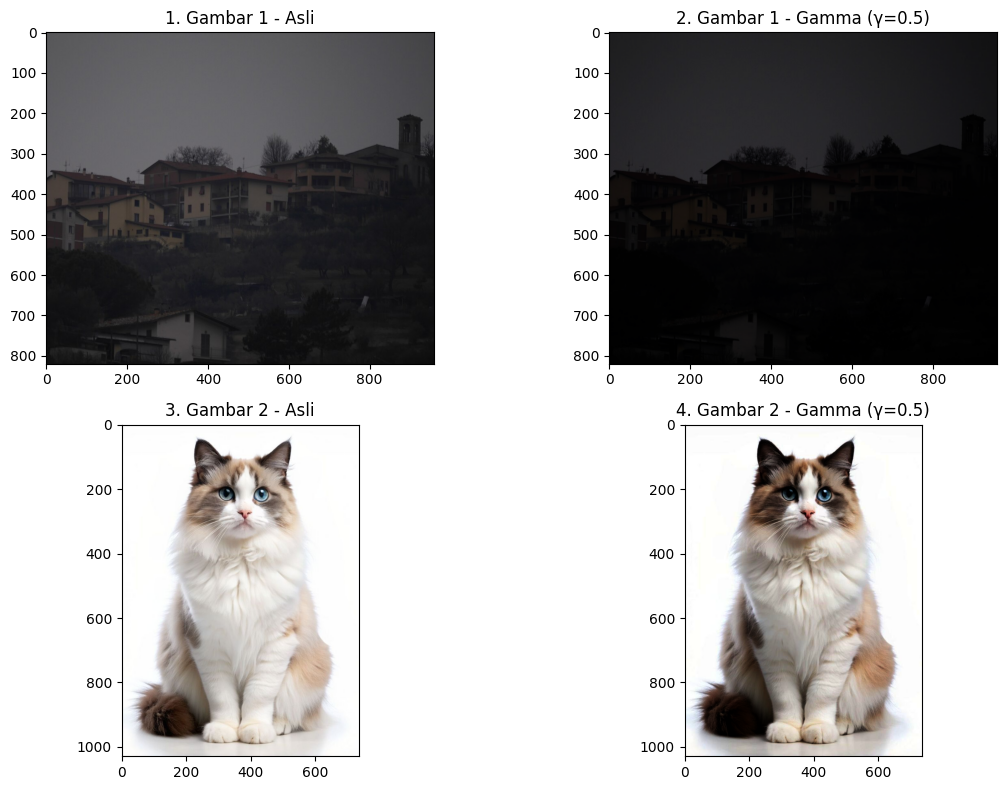

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
level = 255.0 / (pow(2, bit_depth) - 1)

original1 = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg', cv.IMREAD_GRAYSCALE)
original2 = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg', cv.IMREAD_GRAYSCALE)

depth_image1 = (np.round(original1 / level) * level).astype(np.uint8)
depth_image2 = (np.round(original2 / level) * level).astype(np.uint8)

print(f"Bit depth awal  : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level    : {pow(2, bit_depth)}")

plt.figure(figsize=(10, 8))

# Gambar 1
plt.subplot(2, 2, 1)
plt.title('Gambar 1 - Grayscale 8-bit')
plt.imshow(original1, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.title(f'Gambar 1 - Grayscale {bit_depth}-bit')
plt.imshow(depth_image1, cmap='gray')
plt.axis('on')

# Gambar 2
plt.subplot(2, 2, 3)
plt.title('Gambar 2 - Grayscale 8-bit')
plt.imshow(original2, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.title(f'Gambar 2 - Grayscale {bit_depth}-bit')
plt.imshow(depth_image2, cmap='gray')
plt.axis('on')

plt.tight_layout()
plt.show()

nomor 7

$$\text{Interval} = \frac{255}{2^b - 1}$$$$\text{Piksel Baru} = \text{round}\left(\frac{f(x, y)}{\text{Interval}}\right) \times \text{Interval}$$

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


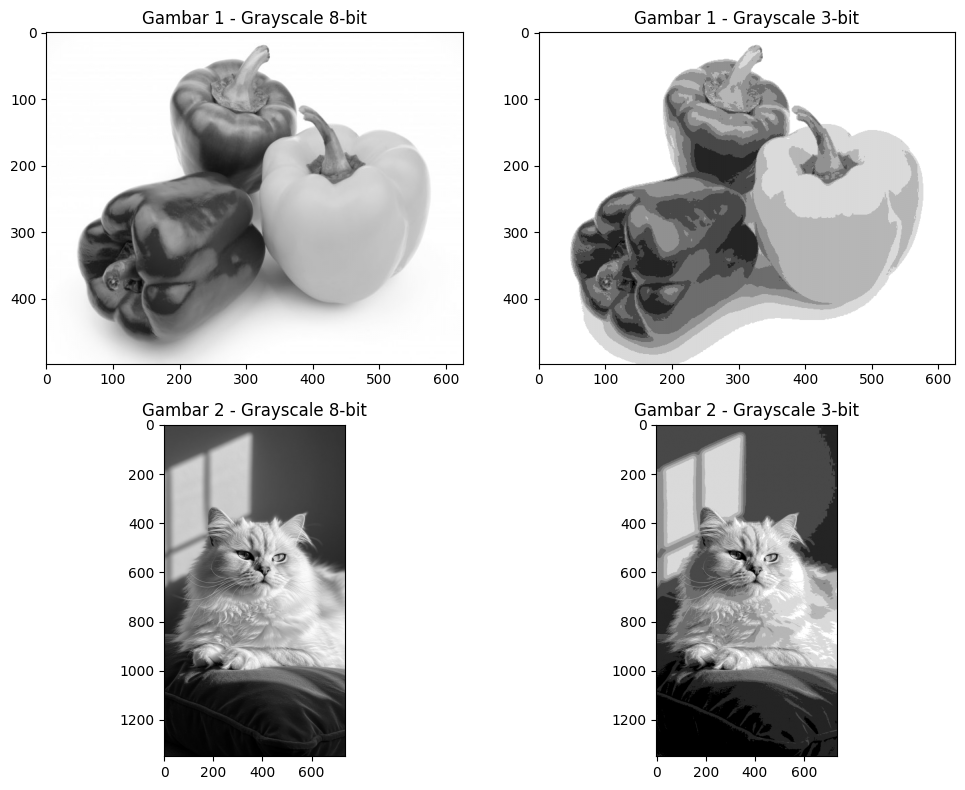

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
level = 255.0 / (pow(2, bit_depth) - 1)

original1 = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg', cv.IMREAD_GRAYSCALE)
original2 = cv.imread('/content/drive/MyDrive/PCVK/kucing2.jpg', cv.IMREAD_GRAYSCALE)

depth_image1 = (np.round(original1 / level) * level).astype(np.uint8)
depth_image2 = (np.round(original2 / level) * level).astype(np.uint8)

print(f"Bit depth awal  : 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level    : {pow(2, bit_depth)}")

plt.figure(figsize=(10, 8))

# Gambar 1
plt.subplot(2, 2, 1)
plt.title('Gambar 1 - Grayscale 8-bit')
plt.imshow(original1, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.title(f'Gambar 1 - Grayscale {bit_depth}-bit')
plt.imshow(depth_image1, cmap='gray')
plt.axis('on')

# Gambar 2
plt.subplot(2, 2, 3)
plt.title('Gambar 2 - Grayscale 8-bit')
plt.imshow(original2, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.title(f'Gambar 2 - Grayscale {bit_depth}-bit')
plt.imshow(depth_image2, cmap='gray')
plt.axis('on')

plt.tight_layout()
plt.show()

nomor 8

1.Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak. Dari data yang didapat, kenaikan nilai PSNR cuma drastis di awal-awal aja (pas dari 10 ke 20 atau 40 gambar). Pas gambar ditambah terus di atas itu, kenaikan PSNR-nya mulai melambat dan perbedaannya tipis banget.

2.Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Kenaikannya mulai datar (nggak begitu kelihatan bedanya) pas masuk ke 40 sampai 80 gambar. Tambahan gambar setelah titik ini nggak terlalu ngefek banyak ke kualitas.

Kesimpulan:
Metode average denoising ini terbukti ampuh buat ngebersihin noise acak pada gambar. Tapi, makin banyak gambar yang dipakai, ada titik jenuhnya. Nyampur lebih dari 40–80 gambar cuma bikin berat komputasi dan makan memori, padahal hasilnya beda tipis secara visual. Jadi, pakai 40 gambar aja udah cukup optimal.

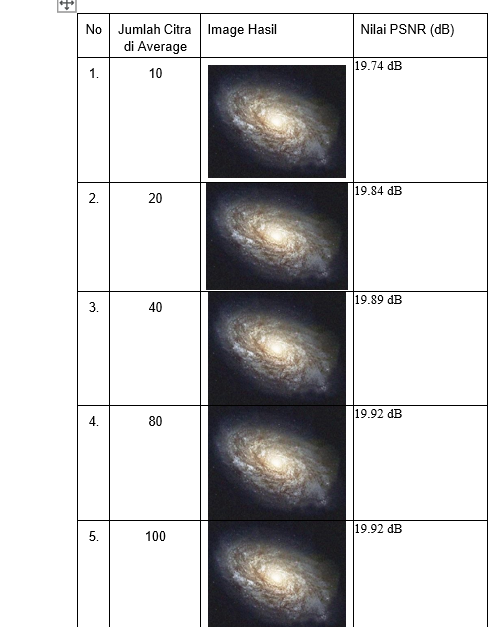

In [ ]:
import cv2 as cv
import numpy as np
import glob
import math

def calc_psnr(img1, img2):

    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    return 20 * math.log10(max_pixel / math.sqrt(mse))


orig_galaxy = cv.imread('/content/drive/MyDrive/PCVK/galaxy.jpg')


if orig_galaxy is None:
    print("ERROR: File 'galaxy.jpg' tidak ditemukan! Cek kembali path dan ejaan nama filenya.")
else:
    noisy_files = sorted(glob.glob('/content/drive/MyDrive/PCVK/noises/*.jpg'))
    cv_img = [cv.imread(f) for f in noisy_files if cv.imread(f) is not None]

    print(f"Total gambar noisy yang berhasil dimuat: {len(cv_img)} file\n")

    if len(cv_img) == 0:
        print("ERROR: Folder 'noises' kosong atau path folder salah!")
    else:
        counts = [10, 20, 40, 80, 100]

        print("No | Jumlah Citra | Nilai PSNR (dB)")
        print("-" * 35)

        for idx, n in enumerate(counts, 1):
            sub_imgs = cv_img[:n]

            if len(sub_imgs) > 0:
                avg_img = np.mean(sub_imgs, axis=0).astype(np.uint8)
                psnr_val = calc_psnr(orig_galaxy, avg_img)
                print(f"{idx:<2} | {n:<12} | {psnr_val:.2f} dB")

Total gambar noisy yang berhasil dimuat: 100 file

No | Jumlah Citra | Nilai PSNR (dB)
-----------------------------------
1  | 10           | 19.74 dB
2  | 20           | 19.84 dB
3  | 40           | 19.89 dB
4  | 80           | 19.92 dB
5  | 100          | 19.92 dB


nomor 9

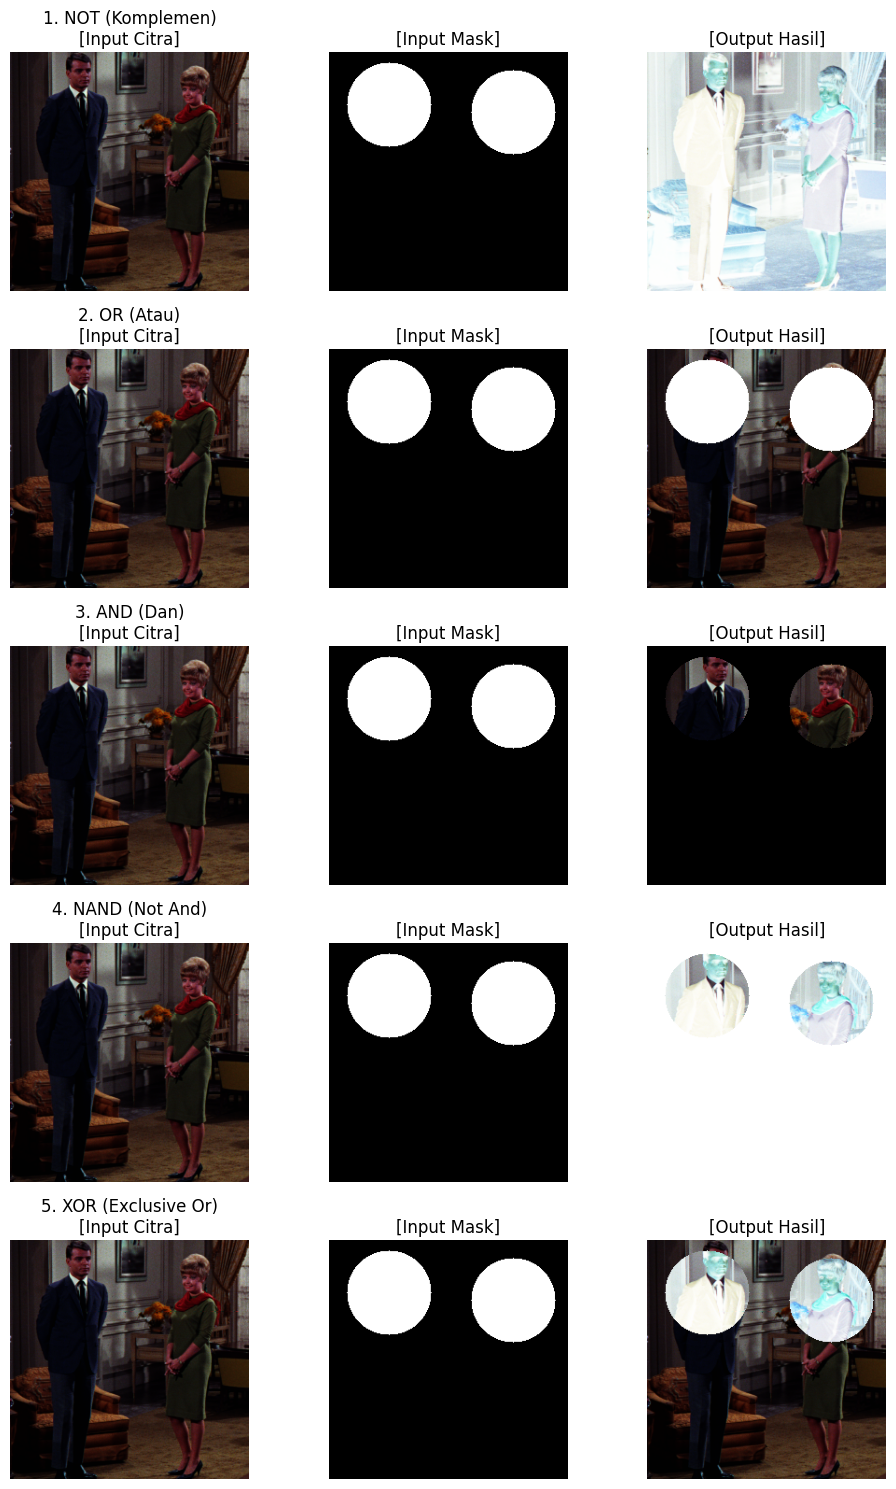

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv.imread('/content/drive/MyDrive/PCVK/couple.tiff')

if img_bgr is not None:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    mask = np.zeros((h, w), dtype=np.uint8)
    cv.circle(mask, (int(w * 0.25), int(h * 0.22)), 45, 255, -1)
    cv.circle(mask, (int(w * 0.77), int(h * 0.25)), 45, 255, -1)

    mask_3ch = cv.merge([mask, mask, mask])

    # 1. NOT (Komplemen)
    res_not = cv.bitwise_not(img_rgb)

    # 2. OR
    res_or = cv.bitwise_or(img_rgb, mask_3ch)

    # 3. AND
    res_and = cv.bitwise_and(img_rgb, mask_3ch)

    # 4. NAND
    res_nand = cv.bitwise_not(res_and)

    # 5. XOR
    res_xor = cv.bitwise_xor(img_rgb, mask_3ch)

    operations = [
        ("1. NOT (Komplemen)", img_rgb, res_not),
        ("2. OR (Atau)", img_rgb, res_or),
        ("3. AND (Dan)", img_rgb, res_and),
        ("4. NAND (Not And)", img_rgb, res_nand),
        ("5. XOR (Exclusive Or)", img_rgb, res_xor)
    ]

    plt.figure(figsize=(10, 15))

    for idx, (title, img_in, img_out) in enumerate(operations, 1):
        plt.subplot(5, 3, (idx - 1) * 3 + 1)
        plt.title(f"{title}\n[Input Citra]")
        plt.imshow(img_in)
        plt.axis('off')

        plt.subplot(5, 3, (idx - 1) * 3 + 2)
        plt.title("[Input Mask]")
        plt.imshow(mask_3ch)
        plt.axis('off')

        plt.subplot(5, 3, (idx - 1) * 3 + 3)
        plt.title("[Output Hasil]")
        plt.imshow(img_out)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

nomor 10

- Metode yang Digunakan:Gamma Correction dengan nilai $\gamma = 0.4$.
- Analisis & Alasan Penanganan:Foto malam hari condong punya pencahayaan yang sangat kurang (underexposed), jadi banyak detail objek di area gelap yang nggak kelihatan. Aku pakai Gamma Correction dengan $\gamma < 1.0$ (di sini aku set $0.4$) karena teknik ini efektif buat mendongkrak intensitas piksel di area gelap tanpa bikin area yang udah terang jadi terlalu silau (overexposed).

- Risiko:Kalau nilai gamma-nya diset kelewat kecil (misalnya $\gamma < 0.2$), warna di area yang agak terang bakal keputihan banget (clipping) dan noise atau bintik-bintik di area gelap malah makin kelihatan jelas.

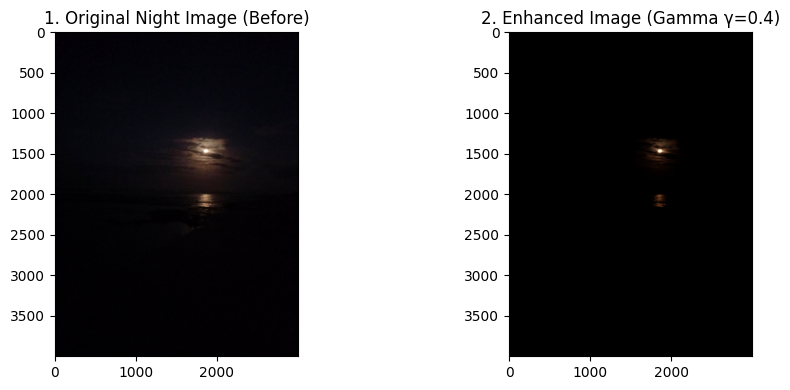

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv.imread('/content/drive/MyDrive/PCVK/malam.jpg')

if img_bgr is not None:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    gamma = 0.4
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    enhanced_rgb = cv.LUT(img_rgb, table)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title('1. Original Night Image (Before)')
    plt.imshow(img_rgb)
    plt.axis('on')

    plt.subplot(1, 2, 2)
    plt.title(f'2. Enhanced Image (Gamma γ={gamma})')
    plt.imshow(enhanced_rgb)
    plt.axis('on')

    plt.tight_layout()
    plt.show()

nomor 11

- Metode yang Digunakan:
CLAHE (Contrast Limited Adaptive Histogram Equalization) pada channel Luminance (L) di ruang warna LAB.

- Analisis & Alasan Penanganan:
Kondisi awal gambar crayfish.jpg kelihatan pudar, agak buram, dan kontrasnya rendah banget. Biar detail tekstur udangnya keluar tapi warnanya nggak berubah aneh, aku konversi dulu fotonya ke ruang warna LAB. Setelah itu, CLAHE cuma diterapkan di channel L (cahaya/luminance)-nya aja dengan clipLimit = 3.0 dan ukuran ubin tileGridSize = (8, 8).

Hasilnya, kontras dan tekstur tajam udangnya langsung kelihatan jelas banget tanpa merusak warna alami dari objek aslinya.

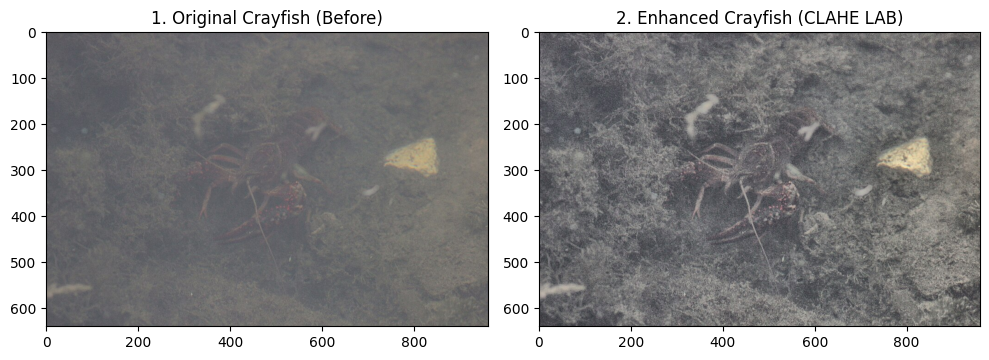

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar crayfish
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/crayfish.jpg')

if img_bgr is not None:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)

    clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    limg = cv.merge((cl, a, b))
    enhanced_bgr = cv.cvtColor(limg, cv.COLOR_LAB2BGR)
    enhanced_rgb = cv.cvtColor(enhanced_bgr, cv.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title('1. Original Crayfish (Before)')
    plt.imshow(img_rgb)
    plt.axis('on')

    plt.subplot(1, 2, 2)
    plt.title('2. Enhanced Crayfish (CLAHE LAB)')
    plt.imshow(enhanced_rgb)
    plt.axis('on')

    plt.tight_layout()
    plt.show()